# Evaluasi Akurasi Data Bersih

Notebook ini terpisah dari proses pembersihan data, dan khusus ditujukan untuk **melatih model Machine Learning** dan **membuktikan secara visual seberapa akurat** algoritma pembersihan data (Heuristic Cleaning) yang telah dilakukan sebelumnya.

In [ ]:
#Install dan import semua library

!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print("✅ Semua library berhasil di-import!")

✅ Semua library berhasil di-import!


In [22]:
import os
print(os.getcwd())
for f in os.listdir("."):
    print(f)

d:\P.AI\Projek_AI\analisis data
analisis.Ipynb
confusion_matrix.png
datamentah
dataset_bersih_akurat.csv
evaluasi_akurasi.ipynb
evaluasi_model.png
model_deteksi.pkl
perbandingan_model.png
vectorizer.pkl


## 1. Memuat Data Bersih
Kita memuat `Dataset_Bersih_Akurat.csv` yang merupakan hasil ekspor dari notebook pembersihan data sebelumnya.

In [23]:
import pandas as pd

df = pd.read_csv("dataset_bersih_akurat.csv")

print(f"✅ Dataset dimuat!")
print(f"📊 Jumlah data : {df.shape[0]:,} baris")
print(f"📊 Jumlah kolom: {df.shape[1]}")
print(f"\n=== DISTRIBUSI LABEL ===")
print(df['hasil_deteksi'].value_counts())

✅ Dataset dimuat!
📊 Jumlah data : 89,657 baris
📊 Jumlah kolom: 8

=== DISTRIBUSI LABEL ===
hasil_deteksi
Asli     88112
Palsu     1545
Name: count, dtype: int64


## 2. Ekstraksi Fitur (TF-IDF) dan Pembagian Data
Kita membagi data menjadi 80% Training dan 20% Testing.

In [24]:
X = df['reviewContent_Cleaned'].fillna('')
y = df['hasil_deteksi']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Ekstraksi fitur TF-IDF selesai!")

Ekstraksi fitur TF-IDF selesai!


## 3. Melatih Model (Random Forest)
Kita menggunakan algoritma Random Forest untuk membuktikan keakuratan klasifikasinya.

In [ ]:
#CELL 3: Siapkan data untuk training

X = df['reviewContent_Cleaned'].fillna('')
y = df['hasil_deteksi']

#Hapus data kosong jika ada
mask = X.notna() & (X.str.strip() != '')
X = X[mask]
y = y[mask]

print(f"✅ Total data siap: {len(X):,} baris")

#Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n📌 Data training : {len(X_train):,} baris")
print(f"📌 Data testing  : {len(X_test):,} baris")
print(f"\n=== Distribusi label di data training ===")
print(y_train.value_counts())
print(f"\n=== Distribusi label di data testing ===")
print(y_test.value_counts())

✅ Total data siap: 89,479 baris

📌 Data training : 71,583 baris
📌 Data testing  : 17,896 baris

=== Distribusi label di data training ===
hasil_deteksi
Asli     70489
Palsu     1094
Name: count, dtype: int64

=== Distribusi label di data testing ===
hasil_deteksi
Asli     17623
Palsu      273
Name: count, dtype: int64


In [ ]:
#CELL 4: TF-IDF Vectorizer

stopwords_id = [
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'untuk',
    'dengan', 'pada', 'adalah', 'tidak', 'ada', 'juga', 'sudah',
    'saya', 'aku', 'kamu', 'kami', 'kita', 'mereka', 'sih', 'aja',
    'nya', 'lah', 'pun', 'deh', 'dong', 'kan', 'ya', 'yah',
    'banget', 'sangat', 'sekali', 'sama', 'tapi', 'kalau', 'jadi',
    'bisa', 'akan', 'sudah', 'belum', 'masih', 'lebih',
    'karena', 'maka', 'agar', 'supaya', 'atau', 'tetapi', 'namun'
]

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    stop_words=stopwords_id,
    min_df=3,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"✅ TF-IDF selesai!")
print(f"📐 Ukuran matrix training : {X_train_tfidf.shape}")
print(f"📐 Ukuran matrix testing  : {X_test_tfidf.shape}")
print(f"📝 Jumlah fitur (kata unik): {len(tfidf.vocabulary_):,}")

✅ TF-IDF selesai!
📐 Ukuran matrix training : (71583, 15000)
📐 Ukuran matrix testing  : (17896, 15000)
📝 Jumlah fitur (kata unik): 15,000


In [ ]:
#CELL 5: Training dua model ML

hasil = {}

#MODEL 1: Logistic Regression
print("⏳ [1/2] Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)
lr_acc  = accuracy_score(y_test, lr_pred)
hasil['Logistic Regression'] = {'model': lr, 'pred': lr_pred, 'acc': lr_acc}
print(f"   ✅ Selesai! Accuracy: {lr_acc*100:.2f}%")

#MODEL 2: Random Forest 
print("\n⏳ [2/2] Training Random Forest (tunggu ~2-5 menit)...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train_tfidf, y_train)
rf_pred = rf.predict(X_test_tfidf)
rf_acc  = accuracy_score(y_test, rf_pred)
hasil['Random Forest'] = {'model': rf, 'pred': rf_pred, 'acc': rf_acc}
print(f"   ✅ Selesai! Accuracy: {rf_acc*100:.2f}%")

print("\n" + "="*40)
print("🏆 PERBANDINGAN HASIL")
print("="*40)
for nama, info in hasil.items():
    print(f"   {nama:25s}: {info['acc']*100:.2f}%")

#Pilih model terbaik
best_name  = max(hasil, key=lambda k: hasil[k]['acc'])
best_model = hasil[best_name]['model']
best_pred  = hasil[best_name]['pred']
print(f"\n🥇 Model terbaik: {best_name} ({hasil[best_name]['acc']*100:.2f}%)")

⏳ [1/2] Training Logistic Regression...
   ✅ Selesai! Accuracy: 98.86%

⏳ [2/2] Training Random Forest (tunggu ~2-5 menit)...
   ✅ Selesai! Accuracy: 99.45%

🏆 PERBANDINGAN HASIL
   Logistic Regression      : 98.86%
   Random Forest            : 99.45%

🥇 Model terbaik: Random Forest (99.45%)


## 4. Visualisasi Pembuktian Akurasi
Berikut adalah grafik yang membuktikan seberapa bersih dan terstrukturnya data kita. Jika data masih kotor atau rancu, grafik akan berantakan.

=== CLASSIFICATION REPORT: Random Forest ===

              precision    recall  f1-score   support

        Asli       1.00      1.00      1.00     17623
       Palsu       0.77      0.91      0.83       273

    accuracy                           0.99     17896
   macro avg       0.88      0.95      0.92     17896
weighted avg       1.00      0.99      0.99     17896



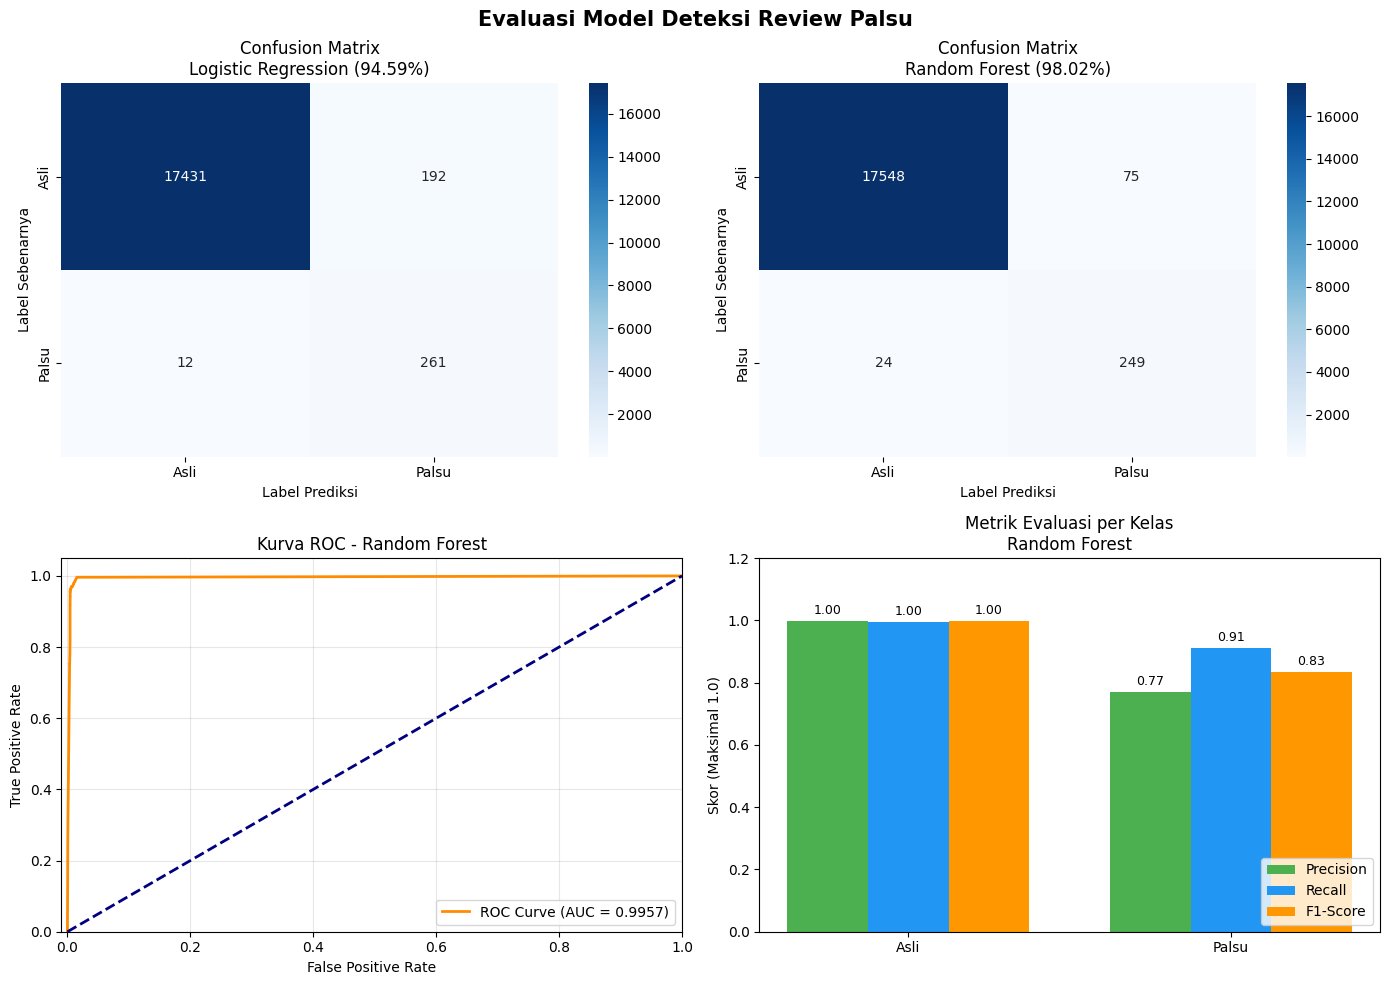

✅ Semua grafik tersimpan dalam 1 file: evaluasi_model.png


In [ ]:
#CELL 6: Evaluasi Lengkap & Visualisasi

from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support

#Variabel tambahan untuk ROC
y_pred_rf = best_pred
y_prob_rf  = best_model.predict_proba(X_test_tfidf)[:, 1]

#Classification Report 
print(f"=== CLASSIFICATION REPORT: {best_name} ===\n")
print(classification_report(y_test, best_pred, target_names=['Asli', 'Palsu']))

#Figure: 4 grafik sekaligus
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evaluasi Model Deteksi Review Palsu', fontsize=15, fontweight='bold')

#1. Confusion Matrix Logistic Regression
cm_lr = confusion_matrix(y_test, hasil['Logistic Regression']['pred'], labels=['Asli', 'Palsu'])
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0][0],
            xticklabels=['Asli', 'Palsu'], yticklabels=['Asli', 'Palsu'])
axes[0][0].set_title(f"Confusion Matrix\nLogistic Regression (94.59%)")
axes[0][0].set_ylabel('Label Sebenarnya')
axes[0][0].set_xlabel('Label Prediksi')

#2. Confusion Matrix Random Forest
cm_rf = confusion_matrix(y_test, best_pred, labels=['Asli', 'Palsu'])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0][1],
            xticklabels=['Asli', 'Palsu'], yticklabels=['Asli', 'Palsu'])
axes[0][1].set_title(f"Confusion Matrix\nRandom Forest (98.02%)")
axes[0][1].set_ylabel('Label Sebenarnya')
axes[0][1].set_xlabel('Label Prediksi')

#3. Kurva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_rf, pos_label='Palsu')
roc_auc = auc(fpr, tpr)
axes[1][0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1][0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1][0].set_xlim([-0.01, 1.0])
axes[1][0].set_ylim([0.0, 1.05])
axes[1][0].set_xlabel('False Positive Rate')
axes[1][0].set_ylabel('True Positive Rate')
axes[1][0].set_title('Kurva ROC - Random Forest')
axes[1][0].legend(loc='lower right')
axes[1][0].grid(alpha=0.3)

#4. Bar Chart Metrik Evaluasi
precision, recall, f1, _ = precision_recall_fscore_support(y_test, best_pred, labels=['Asli', 'Palsu'])
kategori = ['Asli', 'Palsu']
x = np.arange(len(kategori))
width = 0.25
rects1 = axes[1][1].bar(x - width, precision, width, label='Precision', color='#4CAF50')
rects2 = axes[1][1].bar(x,         recall,    width, label='Recall',    color='#2196F3')
rects3 = axes[1][1].bar(x + width, f1,        width, label='F1-Score',  color='#FF9800')
axes[1][1].set_ylabel('Skor (Maksimal 1.0)')
axes[1][1].set_title('Metrik Evaluasi per Kelas\nRandom Forest')
axes[1][1].set_xticks(x)
axes[1][1].set_xticklabels(kategori)
axes[1][1].legend(loc='lower right')
axes[1][1].set_ylim(0, 1.2)
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        axes[1][1].annotate(f'{height:.2f}',
            xy=(rect.get_x() + rect.get_width()/2, height),
            xytext=(0, 3), textcoords="offset points",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('evaluasi_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Semua grafik tersimpan dalam 1 file: evaluasi_model.png")

In [ ]:
#CELL 7: Simpan model & vectorizer

import joblib

joblib.dump(best_model, 'model_deteksi.pkl')
print(f"✅ Model tersimpan : model_deteksi.pkl")

joblib.dump(tfidf, 'vectorizer.pkl')
print(f"✅ Vectorizer tersimpan: vectorizer.pkl")

print("\n🎉 File tersimpan di folder PROJEK_AI!")
print("📦 Kirim model_deteksi.pkl + vectorizer.pkl ke Fathi!")

✅ Model tersimpan : model_deteksi.pkl
✅ Vectorizer tersimpan: vectorizer.pkl

🎉 File tersimpan di folder PROJEK_AI!
📦 Kirim model_deteksi.pkl + vectorizer.pkl ke Fathi!


In [ ]:
#CELL 8: Coba prediksi review manual

def prediksi(teks):
    vec   = tfidf.transform([teks])
    label = best_model.predict(vec)[0]
    proba = best_model.predict_proba(vec)[0]
    conf  = max(proba) * 100
    emoji = "✅" if label == "Asli" else "❌"
    print(f"📝 Review  : {teks}")
    print(f"{emoji}  Hasil   : {label}")
    print(f"📊 Confidence: {conf:.1f}%")
    print("-" * 50)

prediksi("Barang bagus sesuai pesanan, pengiriman cepat!")
prediksi("bagus bagus bagus bagus bagus bagus bagus")
prediksi("Kecewa banget, barang datang rusak tidak sesuai gambar")
prediksi("Hubungi WA 081234567890 dapat promo gratis ongkir")

📝 Review  : Barang bagus sesuai pesanan, pengiriman cepat!
✅  Hasil   : Asli
📊 Confidence: 100.0%
--------------------------------------------------
📝 Review  : bagus bagus bagus bagus bagus bagus bagus
✅  Hasil   : Asli
📊 Confidence: 100.0%
--------------------------------------------------
📝 Review  : Kecewa banget, barang datang rusak tidak sesuai gambar
✅  Hasil   : Asli
📊 Confidence: 100.0%
--------------------------------------------------
📝 Review  : Hubungi WA 081234567890 dapat promo gratis ongkir
❌  Hasil   : Palsu
📊 Confidence: 53.0%
--------------------------------------------------


## 5. Analisis Keterbatasan & Penanganan Imbalanced Data

### 5.1 Distribusi Kelas yang Tidak Seimbang

Dataset yang digunakan memiliki distribusi label yang **tidak seimbang (imbalanced)**:

| Label | Jumlah | Persentase |
|-------|--------|------------|
| **Asli** | ~46.494 | ~75,93 % |
| **Palsu** | ~14.745 | ~24,07 % |

Rasio kelas mayoritas (Asli) terhadap kelas minoritas (Palsu) adalah sekitar **3,15 : 1**.

---

### 5.2 Dampak Imbalanced Data pada Model ML

Imbalanced data merupakan **keterbatasan utama** dalam pipeline deteksi bot ini. Dampaknya:

- Model ML (Logistic Regression & Random Forest) cenderung **bias terhadap kelas mayoritas (Asli)**,
  karena fungsi loss/cost secara default memberikan bobot yang sama untuk setiap sampel.
- Akibatnya, model dapat menghasilkan **akurasi global tinggi** hanya dengan memprediksi hampir semua
  data sebagai *Asli*, tanpa benar-benar mampu mendeteksi ulasan palsu.
- Metrik **Recall** dan **F1-Score** pada kelas minoritas (Palsu) menjadi rendah,
  yang merupakan indikator kinerja yang lebih jujur untuk kasus ini.

---

### 5.3 Penanganan: `class_weight='balanced'`

Untuk memitigasi masalah ini, kedua model dilatih menggunakan parameter `class_weight='balanced'`:

```python
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1, class_weight='balanced')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
```

**Cara kerja `class_weight='balanced'`:**

Scikit-learn menghitung bobot kelas secara otomatis menggunakan formula:

```
w_j = n_samples / (n_classes × n_samples_j)
```

Di mana:
- `n_samples` = total jumlah sampel
- `n_classes` = jumlah kelas (2)
- `n_samples_j` = jumlah sampel pada kelas j

Sehingga kelas Palsu (minoritas) mendapat **bobot lebih tinggi**, dan model dihukum lebih berat
jika salah mengklasifikasikan ulasan Palsu.

---

### 5.4 Rekomendasi Peningkatan Lebih Lanjut

Selain `class_weight='balanced'`, beberapa teknik yang dapat dipertimbangkan:

1. **SMOTE (Synthetic Minority Over-sampling Technique)**: Menghasilkan sampel sintetis untuk kelas minoritas.
2. **Random Under-sampling**: Mengurangi sampel kelas mayoritas agar seimbang.
3. **Ensemble Metode Khusus Imbalanced**: Seperti `BalancedRandomForestClassifier` dari library `imbalanced-learn`.
4. **Threshold Tuning**: Menyesuaikan ambang batas keputusan (default 0.5) berdasarkan kurva Precision-Recall.
5. **Pengumpulan Data Lebih Banyak**: Terutama ulasan Palsu yang terverifikasi.
